# 01 — Data Exploration

**Goal:** Pull all FRED series, verify shapes, date ranges, and confirm 
the series IDs in `preprocessing_config.yaml` are active and returning data.

**Outputs:**
- Summary table: series_id, start_date, end_date, obs_count, latest_value
- Quick time series plots for each series
- Identify any gaps, discontinuations, or surprises

**Prerequisites:** Set `FRED_API_KEY` in your `.env` file.

In [1]:
import os
import sys
from pathlib import Path

# Add backend to path so we can import project modules
sys.path.insert(0, str(Path.cwd().parent / 'backend'))

from dotenv import load_dotenv
load_dotenv(Path.cwd().parent / 'backend' / '.env')

import pandas as pd
import matplotlib.pyplot as plt
import yaml

from data.ingestion import load_series_config, generate_dummy_series

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

In [2]:
# Load series config
config = load_series_config()
print(f'{len(config)} series configured')
for s in config:
    print(f"  {s['id']:40s} {s['frequency']:10s} role={s['role']}")

18 series configured
  UTEDUH                                   monthly    role=target
  SMU49000006562100001SA                   monthly    role=target_secondary
  UTNA                                     monthly    role=feature
  UTURN                                    monthly    role=feature
  LBSSA49                                  monthly    role=context
  UTICLAIMS                                weekly     role=feature
  UTCCLAIMS                                weekly     role=context
  SMU49000000500000003                     monthly    role=feature
  CES6562000001                            monthly    role=context
  JTS6200JOL                               monthly    role=feature
  JTS6200JOR                               monthly    role=feature
  JTS6200QUR                               monthly    role=feature
  JTS6200HIL                               monthly    role=feature
  CES6500000003                            monthly    role=feature
  ECIALLCIV                      

In [3]:
# Option A: Fetch from FRED (requires API key)
from data.ingestion import fetch_all_series
raw = fetch_all_series()

# Option B: Use dummy data for development
# raw = generate_dummy_series()
# print(f'Loaded {len(raw)} series')

  ✓ UTEDUH — 253 observations
  ✓ SMU49000006562100001SA — 253 observations
  ✓ UTNA — 253 observations
  ✓ UTURN — 253 observations
  ✓ LBSSA49 — 253 observations
  ✓ UTICLAIMS — 1110 observations
  ✓ UTCCLAIMS — 1109 observations
  ✓ SMU49000000500000003 — 229 observations
  ✓ CES6562000001 — 255 observations
  ✓ JTS6200JOL — 254 observations
  ✓ JTS6200JOR — 254 observations
  ✓ JTS6200QUR — 254 observations
  ✓ JTS6200HIL — 254 observations
  ✓ CES6500000003 — 241 observations
  ✓ ECIALLCIV — 84 observations
  ✓ UNRATE — 255 observations
  ✓ CPIAUCSL — 255 observations
  ✓ FEDFUNDS — 255 observations


In [5]:
summary = []
for sid, data in raw.items():
    summary.append({
        'series_id': sid,
        'start': data.index.min().strftime('%Y-%m'),
        'end': data.index.max().strftime('%Y-%m'),
        'obs_count': len(data),
        'latest_value': round(data.iloc[-1], 2),
    })

pd.DataFrame(summary).set_index('series_id')

,start,end,obs_count,latest_value
series_id,,,,
UTEDUH,2005-01,2026-01,253,253.40
SMU49000006562100001SA,2005-01,2026-01,253,86.46
UTNA,2005-01,2026-01,253,1775.40
UTURN,2005-01,2026-01,253,4.00
LBSSA49,2005-01,2026-01,253,67.50
UTICLAIMS,2005-01,2026-04,1110,1646.00
UTCCLAIMS,2005-01,2026-03,1109,12964.00
SMU49000000500000003,2007-01,2026-01,229,36.00
CES6562000001,2005-01,2026-03,255,23756.50


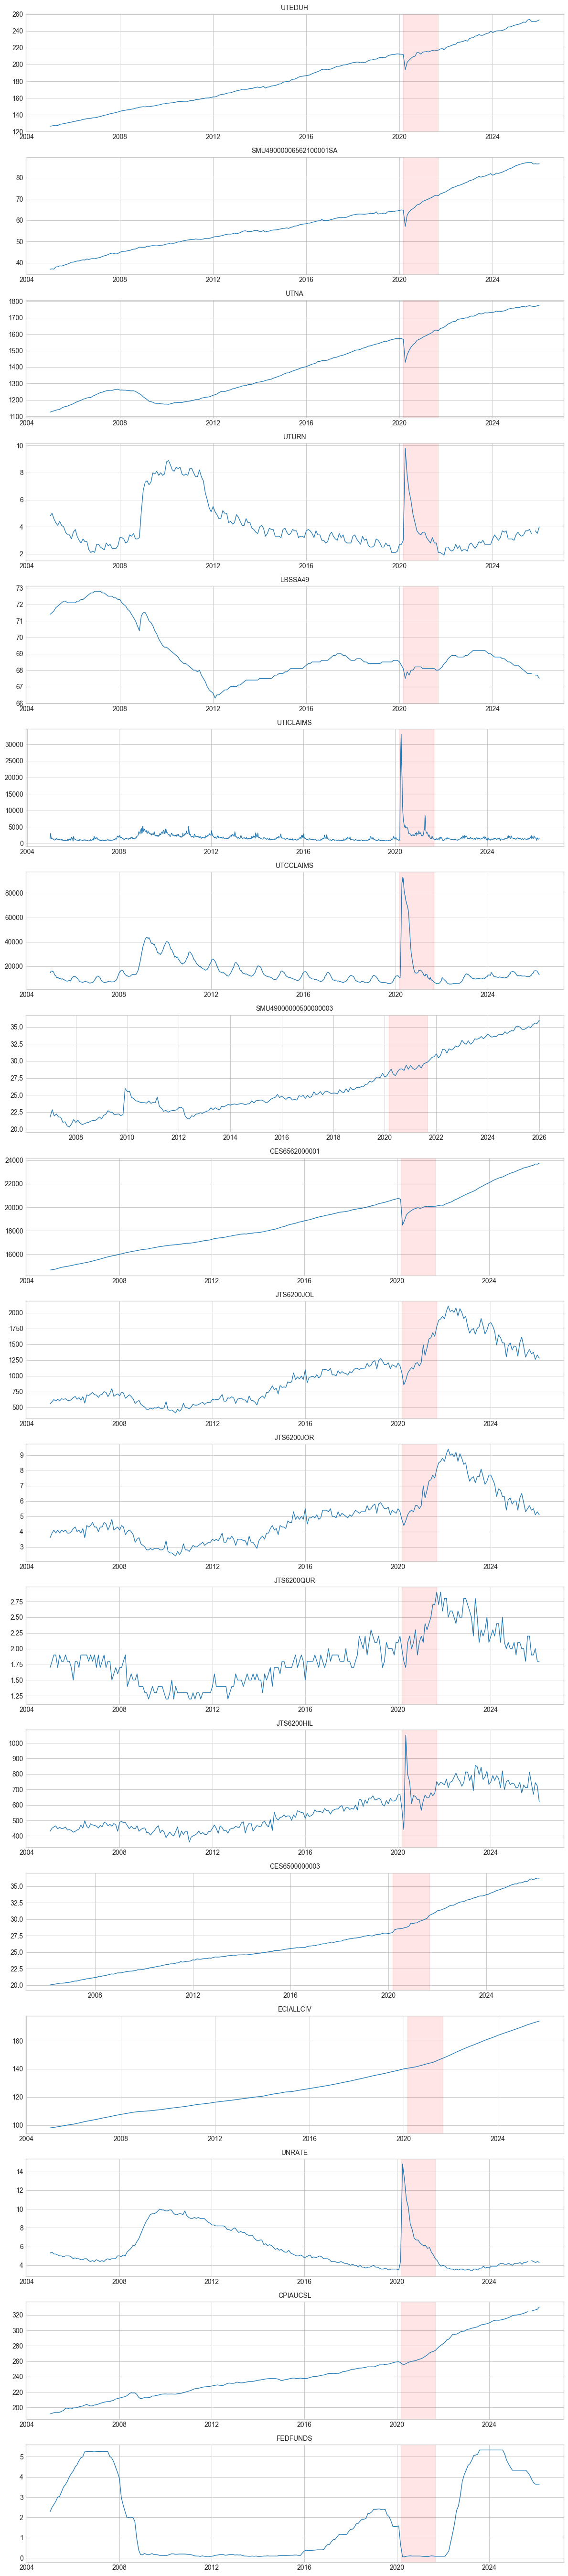

In [7]:
# Quick plots
fig, axes = plt.subplots(len(raw), 1, figsize=(12, 3 * len(raw)), sharex=False)
if len(raw) == 1:
    axes = [axes]

for ax, (sid, data) in zip(axes, raw.items()):
    ax.plot(data.index, data.values, linewidth=1)
    ax.set_title(sid, fontsize=10)
    ax.axvspan('2020-03-01', '2021-09-01', alpha=0.1, color='red', label='COVID')

plt.tight_layout()
plt.show()

## Next Steps

- [ ] Confirm all series IDs return data from FRED
- [ ] Note any series with gaps or unexpected date ranges
- [ ] Proceed to `02_stationarity_analysis.ipynb`